# **Delayed Onset Diagnosis**

##### Imports and Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [3]:
demographics = pd.read_excel("Demographics_PHI.xlsx")
diagnosis = pd.read_excel("Diagnosis.xlsx")

### Delayed Diagnoses (by Disease)

#### ALS

In [ ]:
# Taking diagnosis date and symptom onset date, finding difference
als_dates = diagnosis[diagnosis["dstype"] == "ALS"][["alsdgndt", "alsonsdt", "FACILITY_NAME", "bdypt"]].copy()

date_cols = ["alsdgndt", "alsonsdt"]
als_dates[date_cols] = als_dates[date_cols].apply(pd.to_datetime())

als_dates["delay"] = (als_dates["alsdgndt"] - als_dates["alsonsdt"]).dt.days

#Diagnosis should always occur after symptom onset (filtering out negative deltas)
als_dates = als_dates[als_dates["delay"] >= 0]

/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/2598583076.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  als_dates[date_cols] = als_dates[date_cols].apply(pd.to_datetime)
/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/2598583076.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  als_dates[date_cols] = als_dates[date_cols].apply(pd.to_datetime)


In [10]:
diagnosis["alsdgndt"].value_counts()

alsdgndt
01/01/2018 12:00:00 AM    30
01/01/2020 12:00:00 AM    25
01/01/2013 12:00:00 AM    19
01/01/2015 12:00:00 AM    18
01/01/2022 12:00:00 AM    17
                          ..
09/14/2023 12:00:00 AM     1
07/08/2024 12:00:00 AM     1
05/19/2021 12:00:00 AM     1
11/18/2019 12:00:00 AM     1
02/26/2020 12:00:00 AM     1
Name: count, Length: 1772, dtype: int64

##### Broad Statistics

Mean diagnosis delay: 676.540006375518
Median diagnosis delay: 395.0
Max diagnosis delay: 37280.0
Total diagnoses: 3137


<Axes: xlabel='delay', ylabel='Density'>

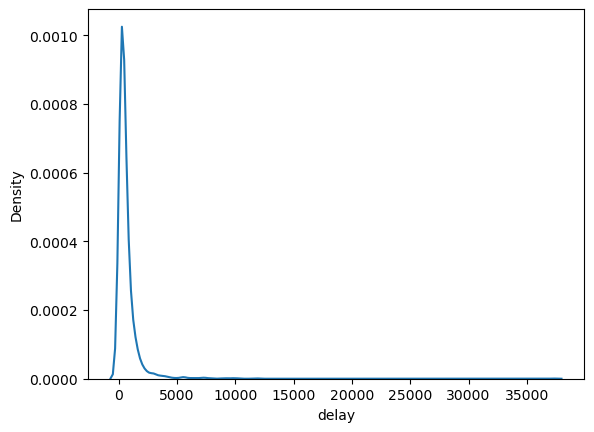

In [4]:
print(f"Mean diagnosis delay: {als_dates["delay"].mean()}")
print(f"Median diagnosis delay: {als_dates["delay"].median()}")
print(f"Max diagnosis delay: {als_dates["delay"].max()}")
print(f"Total diagnoses: {len(als_dates)}")

sns.kdeplot(data = als_dates, x = "delay")

##### Grouping by Facility

In [5]:
facility = als_dates.groupby(["FACILITY_NAME"]).agg(
    median_delay = ("delay", "median"),
    num_observations = ("delay", "count")
).reset_index()

#Facilities with the highest delay in diagnosis
facility.sort_values(by = "median_delay", ascending = False).head(10)

,FACILITY_NAME,median_delay,num_observations
13,Las Vegas Clinic,1887.0,3
11,Idaho Physical Medicine & Rehabilitation,790.5,2
18,Monmouth Medical Center,702.0,14
27,University of Arkansas Medical Sciences,646.0,31
28,University of California San Francisco,563.0,136
14,Louisiana State University Health Science Center,515.0,44
16,Medical College of Wisconsin,494.0,47
2,"Carle Neuroscience Institute, Carle Foundation...",489.5,8
21,Rutgers New Jersey Medical School,445.0,7
8,HSS - Hospital for Special Surgery,429.0,30


In [6]:
#Facilities with the lowest delay in diagnosis
facility.sort_values(by = "median_delay", ascending = True).head(10)

,FACILITY_NAME,median_delay,num_observations
6,Geisinger Medical Center,15.0,2
20,Prevea Health,61.0,2
5,Essentia Health of Duluth,181.0,11
37,Yale University School of Medicine,205.0,3
31,University of Mississippi Medical Center,253.0,2
1,California Pacific University,273.0,31
23,Temple University Hospital,307.0,69
34,University of Vermont Medical Center,322.0,7
26,UCSF Fresno,335.0,15
33,University of Puerto Rico Medical Sciences,337.0,1


#### FSHD

In [7]:
# Taking diagnosis date and symptom onset date, finding difference
fshd_dates = diagnosis[diagnosis["dstype"] == "FSHD"][["fstattndt", "fshdgndt", "FACILITY_NAME"]].copy()

date_cols = ["fstattndt", "fshdgndt"]
fshd_dates[date_cols] = fshd_dates[date_cols].apply(pd.to_datetime)

fshd_dates["delay"] = (fshd_dates["fshdgndt"] - fshd_dates["fstattndt"]).dt.days

# Measuring delay as difference between diagnosis date and medical attention date
fshd_dates = fshd_dates[fshd_dates["delay"] >= 0]

/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/1501063436.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fshd_dates[date_cols] = fshd_dates[date_cols].apply(pd.to_datetime)
/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/1501063436.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fshd_dates[date_cols] = fshd_dates[date_cols].apply(pd.to_datetime)


##### Broad Checks

Mean diagnosis delay: 1881.8370786516855
Median diagnosis delay: 365.0
Max diagnosis delay: 16801
Total diagnoses: 178


<Axes: xlabel='delay', ylabel='Density'>

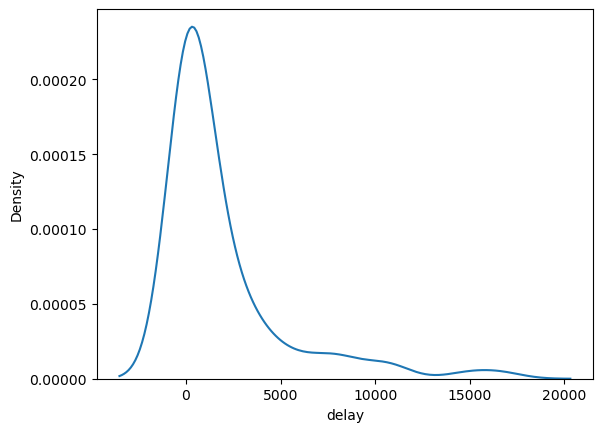

In [8]:
print(f"Mean diagnosis delay: {fshd_dates["delay"].mean()}")
print(f"Median diagnosis delay: {fshd_dates["delay"].median()}")
print(f"Max diagnosis delay: {fshd_dates["delay"].max()}")
print(f"Total diagnoses: {len(fshd_dates)}")


sns.kdeplot(fshd_dates,  x = "delay")

##### Grouping by Facility

In [9]:
facility = fshd_dates.groupby(["FACILITY_NAME"]).agg(
    median_delay = ("delay", "median"),
    num_observations = ("delay", "count")
).reset_index()

facility.sort_values("median_delay", ascending = False).head(10)


,FACILITY_NAME,median_delay,num_observations
34,Yale University School of Medicine,8025.0,1
22,Temple University Hospital,3700.0,6
14,Louisiana State University Health Science Center,3287.0,5
27,University of Miami Kessenich Family Center,2922.0,19
23,UC Irvine Center for Clinical Research,2734.0,12
2,Billings Clinic,1643.5,6
8,Dartmouth-Hitchcock Medical Center,1179.0,2
29,University of Mississippi Medical Center,913.5,2
24,UCLA,913.0,2
13,Idaho Physical Medicine & Rehabilitation,864.0,5


In [10]:
facility.sort_values("median_delay", ascending = True).head(10)


,FACILITY_NAME,median_delay,num_observations
1,"Beaumont Health, Royal Oak",0.0,1
21,Southern Illinois University of Medicine,0.0,3
20,Rutgers New Jersey Medical School,0.0,1
19,Prevea Health,0.0,3
18,Penn State Health,0.0,1
9,Georgetown University,0.0,10
10,HSS - Hospital for Special Surgery,0.0,1
33,Wesley Neurology Clinic,0.0,8
0,Arkansas Children's Research Institute,26.0,1
11,Hospital for Special Care,44.0,13


#### LGMD

In [11]:
# Taking diagnosis date and symptom onset date, finding difference
lgmd_dates = diagnosis[diagnosis["dstype"] == "LGMD"][["lgdgndt","symondt", "FACILITY_NAME"]].copy()

date_cols = ["lgdgndt","symondt"]
lgmd_dates[date_cols] = lgmd_dates[date_cols].apply(pd.to_datetime)

lgmd_dates["delay"] = (lgmd_dates["lgdgndt"] - lgmd_dates["symondt"]).dt.days

# Measuring delay as difference between diagnosis date and symptom onset date
lgmd_dates = lgmd_dates[lgmd_dates["delay"] >= 0]

/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/2070680729.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lgmd_dates[date_cols] = lgmd_dates[date_cols].apply(pd.to_datetime)
/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_29528/2070680729.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lgmd_dates[date_cols] = lgmd_dates[date_cols].apply(pd.to_datetime)


##### Broad Checks

Mean diagnosis delay: 2977.7268292682925
Median diagnosis delay: 1734.0
Max diagnosis delay: 19358.0
Total diagnoses: 205


<Axes: xlabel='delay', ylabel='Density'>

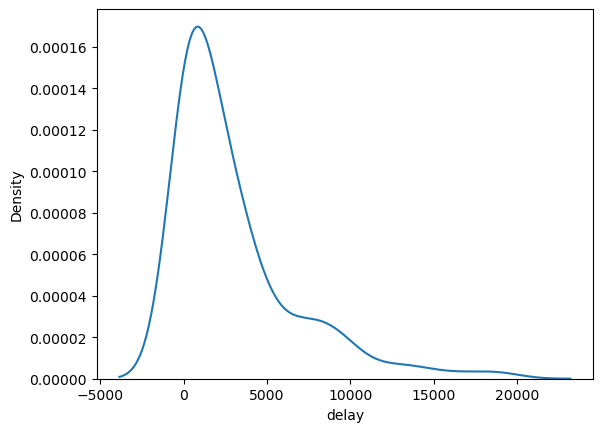

In [12]:
print(f"Mean diagnosis delay: {lgmd_dates["delay"].mean()}")
print(f"Median diagnosis delay: {lgmd_dates["delay"].median()}")
print(f"Max diagnosis delay: {lgmd_dates["delay"].max()}")
print(f"Total diagnoses: {len(lgmd_dates)}")


sns.kdeplot(lgmd_dates,  x = "delay")

##### Grouping by Facility

In [13]:
facility = lgmd_dates.groupby(["FACILITY_NAME"]).agg(
    median_delay = ("delay", "median"),
    num_observations = ("delay", "count")
).reset_index()

#Longest delays
facility.sort_values("median_delay", ascending = False).head(10)


,FACILITY_NAME,median_delay,num_observations
13,Geisinger Medical Center,13788.0,1
11,Dartmouth-Hitchcock Medical Center,6940.0,1
24,Rutgers New Jersey Medical School,5803.0,1
21,Ohio State University Wexner Medical Center,5676.5,8
4,"Carle Neuroscience Institute, Carle Foundation...",4347.0,8
12,Essentia Health of Duluth,3957.0,1
33,University of Miami Kessenich Family Center,3898.0,7
27,UC Irvine Center for Clinical Research,3324.0,14
31,University of Kansas Medical Center,3318.0,16
18,Louisiana State University Health Science Center,3057.0,10


In [103]:
facility.sort_values("median_delay", ascending = True).head(10)


,FACILITY_NAME,median_delay,num_observations
38,Vanderbilt University Medical Center,0.0,2
5,Child Neurology Consultants of Austin,0.0,1
25,Southern Illinois University of Medicine,0.0,2
36,University of Missouri,60.0,8
2,"Beaumont Health, Royal Oak",105.5,2
22,Penn State Health,113.0,6
32,University of Louisville (Pediatrics),347.0,3
9,Children's Hospital of the King's Daughters,365.0,3
37,University of Puerto Rico Medical Sciences,397.0,3
7,Children's Hospital of Philadelphia,410.0,3


#### SMA

In [114]:
# Taking diagnosis date and symptom onset date, finding difference
sma_dates = diagnosis[diagnosis["dstype"] == "SMA"][["smadgndt", "symonset", "FACILITY_NAME", "bdypt"]].copy()

date_cols = ["smadgndt", "symonset"]
sma_dates[date_cols] = sma_dates[date_cols].apply(pd.to_datetime)

sma_dates["delay"] = (sma_dates["smadgndt"] - sma_dates["symonset"]).dt.days

#Diagnosis should always occur after symptom onset (filtering out negative deltas)
sma_dates = sma_dates[sma_dates["delay"] >= 0]

/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_37458/2419898416.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sma_dates[date_cols] = sma_dates[date_cols].apply(pd.to_datetime)
/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_37458/2419898416.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sma_dates[date_cols] = sma_dates[date_cols].apply(pd.to_datetime)


##### Broad Checks

Mean diagnosis delay: 898.1599045346062
Median diagnosis delay: 185.0
Max diagnosis delay: 18993.0
Total diagnoses: 419


<Axes: xlabel='delay', ylabel='Density'>

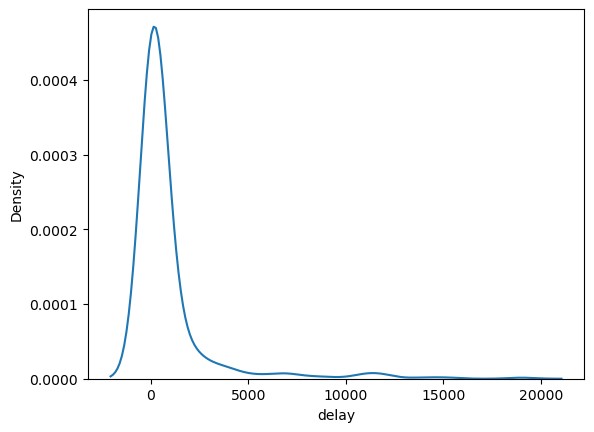

In [124]:
print(f"Mean diagnosis delay: {sma_dates["delay"].mean()}")
print(f"Median diagnosis delay: {sma_dates["delay"].median()}")
print(f"Max diagnosis delay: {sma_dates["delay"].max()}")
print(f"Total diagnoses: {len(sma_dates)}")


sns.kdeplot(data = sma_dates, x = "delay")

##### Grouping by Facility

In [118]:
facility = sma_dates.groupby(["FACILITY_NAME"]).agg(
    median_delay = ("delay", "median"),
    num_observations = ("delay", "count")
).reset_index()

#Facilities with the highest delay in diagnosis
facility.sort_values(by = "median_delay", ascending = False).head(10)

,FACILITY_NAME,median_delay,num_observations
20,Idaho Physical Medicine & Rehabilitation,10946.0,1
18,Hospital for Special Care,6173.0,1
28,Rutgers New Jersey Medical School,4383.0,1
23,Louisiana State University Health Science Center,3653.0,3
30,UC Irvine Center for Clinical Research,3531.0,3
31,UCLA,2827.5,6
38,University of Miami Kessenich Family Center,1826.0,19
29,Temple University Hospital,1826.0,7
41,Wesley Neurology Clinic,1096.0,9
24,Massachusetts General Hospital,913.0,2


In [119]:
#Facilities with the lowest delay in diagnosis
facility.sort_values(by = "median_delay", ascending = True).head(10)

,FACILITY_NAME,median_delay,num_observations
42,Yale University School of Medicine,0.0,3
40,University of Missouri,0.0,3
2,"Beaumont Health, Royal Oak",0.0,9
19,Houston Methodist Neurological Institute,0.0,1
17,HSS - Hospital for Special Surgery,0.0,1
15,Geisinger Medical Center,0.0,1
14,Essentia Health of Duluth,0.0,3
33,UF Health Pediatrics,12.0,3
5,Child Neurology Consultants of Austin,24.5,4
26,Ohio State University Wexner Medical Center,45.5,10


#### Pompe

In [109]:
# Taking diagnosis date and symptom onset date, finding difference
pompe_dates = diagnosis[diagnosis["dstype"] == "Pompe"][["pomdgdt", "symonset", "FACILITY_NAME", "bdypt"]].copy()

date_cols = ["pomdgdt", "symonset"]
pompe_dates[date_cols] = pompe_dates[date_cols].apply(pd.to_datetime)

pompe_dates["delay"] = (pompe_dates["pomdgdt"] - pompe_dates["symonset"]).dt.days

#Diagnosis should always occur after symptom onset (filtering out negative deltas)
pompe_dates = pompe_dates[pompe_dates["delay"] >= 0]

/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_37458/1634298524.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pompe_dates[date_cols] = pompe_dates[date_cols].apply(pd.to_datetime)
/var/folders/rh/wpx_rfjx5g12_15rb0hkc9yh0000gn/T/ipykernel_37458/1634298524.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pompe_dates[date_cols] = pompe_dates[date_cols].apply(pd.to_datetime)


##### Broad Checks

Mean diagnosis delay: 3562.1363636363635
Median diagnosis delay: 3042.0
Max diagnosis delay: 14610.0
Total diagnoses: 22


<Axes: xlabel='delay', ylabel='Density'>

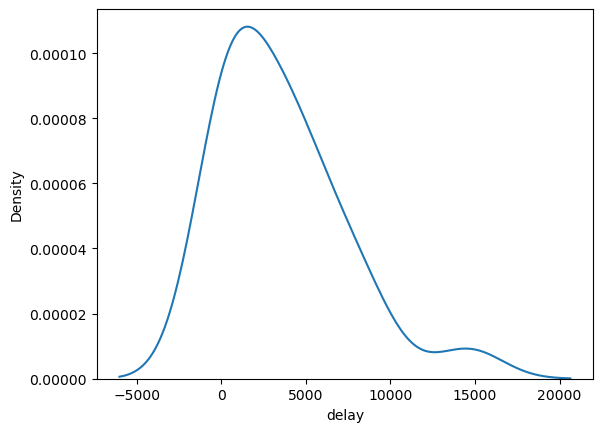

In [125]:
print(f"Mean diagnosis delay: {pompe_dates["delay"].mean()}")
print(f"Median diagnosis delay: {pompe_dates["delay"].median()}")
print(f"Max diagnosis delay: {pompe_dates["delay"].max()}")
print(f"Total diagnoses: {len(pompe_dates)}")


sns.kdeplot(data = pompe_dates, x = "delay")

##### Grouping by Facility

In [113]:
facility = pompe_dates.groupby(["FACILITY_NAME"]).agg(
    median_delay = ("delay", "median"),
    num_observations = ("delay", "count")
).reset_index()

#Facilities with the highest delay in diagnosis
facility.sort_values(by = "median_delay", ascending = False)

,FACILITY_NAME,median_delay,num_observations
4,Hospital for Special Care,8489.5,2
11,Wesley Neurology Clinic,7305.0,1
2,"Carle Neuroscience Institute, Carle Foundation...",4222.0,2
6,Prevea Health,4195.0,4
10,University of Miami Kessenich Family Center,3957.0,3
3,HSS - Hospital for Special Surgery,3663.0,1
7,UC Irvine Center for Clinical Research,1954.5,2
1,Billings Clinic,895.0,2
8,UF Health Pediatrics,581.0,2
5,Nemours Children's Hospital,367.0,1


#### Extra Notes

- When examining BMD and DMD, there doesn't appear to be a symptom onset date, would it be useful to examine discrepancies between genetic test date and diagnosis date?